# Handling Imbalanced Data

**Imbalanced datasets** occur when one class significantly outnumbers another. This is extremely common in real-world problems:
- Fraud detection (0.1% fraudulent transactions)
- Medical diagnosis (rare disease occurrence)
- Network intrusion detection
- Churn prediction

This notebook covers the full spectrum of techniques from oversampling to ensemble methods.

---
**Topics Covered:**
1. The Class Imbalance Problem & Proper Metrics
2. Oversampling Techniques (SMOTE, ADASYN, Borderline-SMOTE, etc.)
3. Undersampling Techniques (NearMiss, Tomek Links, ENN, etc.)
4. Combined Methods (SMOTE-Tomek, SMOTE-ENN)
5. Ensemble Approaches (BalancedBagging, BalancedRandomForest, etc.)
6. When to Use Which Technique
7. Cost-Sensitive Learning
8. End-to-End Fraud Detection Example
9. Additional Learning Resources


In [1]:
# Install imbalanced-learn if needed
# !pip install imbalanced-learn scikit-learn matplotlib seaborn pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve, roc_curve
)
from sklearn.preprocessing import StandardScaler

# imbalanced-learn
from imblearn.over_sampling import (
    RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE,
    SMOTENC, SVMSMOTE
)
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss, TomekLinks,
    EditedNearestNeighbours, RepeatedEditedNearestNeighbours,
    AllKNN, NeighbourhoodCleaningRule, OneSidedSelection,
    ClusterCentroids, InstanceHardnessThreshold
)
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.ensemble import (
    BalancedBaggingClassifier, BalancedRandomForestClassifier,
    EasyEnsembleClassifier, RUSBoostClassifier
)
from imblearn.pipeline import Pipeline as ImbPipeline

print('All imports successful!')
print(f'imbalanced-learn version: ', end='')
import imblearn; print(imblearn.__version__)


All imports successful!
imbalanced-learn version: 0.14.2


## 1. The Class Imbalance Problem

### Why Accuracy Is Misleading

Consider a dataset where 99% of samples are class 0 and 1% are class 1.
A classifier that **always predicts class 0** achieves **99% accuracy** yet it completely fails to detect the minority class.

### Better Metrics for Imbalanced Data

| Metric | Formula | Notes |
|--------|---------|-------|
| Precision | TP / (TP + FP) | Of predicted positives, how many are real? |
| Recall (Sensitivity) | TP / (TP + FN) | Of actual positives, how many did we catch? |
| F1-Score | 2 × (P × R) / (P + R) | Harmonic mean of precision & recall |
| ROC-AUC | Area under ROC curve | Rank-ordering ability across thresholds |
| PR-AUC | Area under Precision-Recall curve | Better for highly imbalanced data |
| G-Mean | √(Sensitivity × Specificity) | Balance across both classes |
| Matthews Correlation Coefficient | TP×TN - FP×FN / √(...) | Balanced metric even with unequal class sizes |

> **Key insight:** For imbalanced datasets, **PR-AUC is often more informative than ROC-AUC** because it focuses on the minority class performance without being inflated by the large number of true negatives.


Dataset shape: (10000, 10)
Class distribution: [9900  100]
Imbalance ratio: 99.0:1

Naive (always 0) classifier:
  Accuracy:  0.9900  <- looks great!
  Recall:    0.0000  <- terrible!
  F1-Score:  0.0000  <- terrible!
  ROC-AUC:   0.5000  <- 0.5 = random!


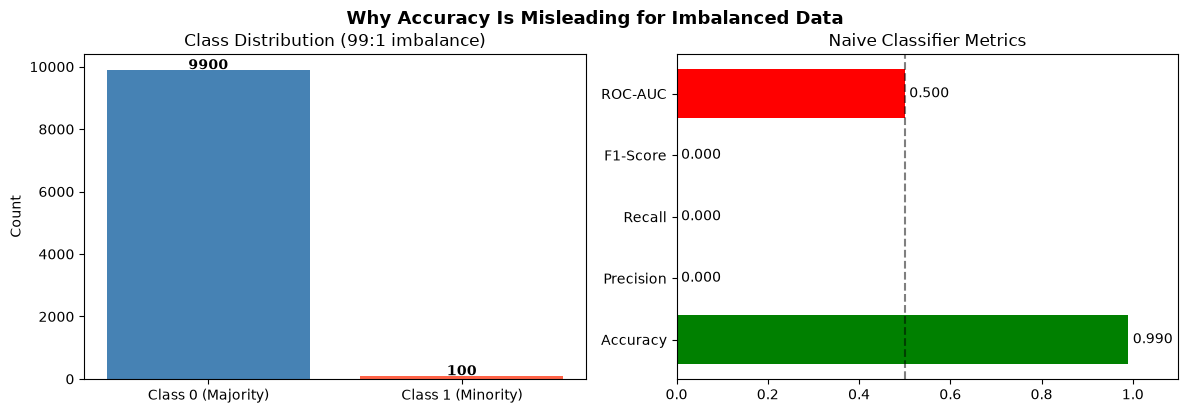

In [2]:
# Demonstrate why accuracy is misleading
np.random.seed(42)

# Create highly imbalanced dataset (1% minority)
X_imb, y_imb = make_classification(
    n_samples=10000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.99, 0.01],
    flip_y=0,
    random_state=42
)

print(f'Dataset shape: {X_imb.shape}')
print(f'Class distribution: {np.bincount(y_imb)}')
print(f'Imbalance ratio: {np.bincount(y_imb)[0]/np.bincount(y_imb)[1]:.1f}:1')

# Naive classifier: always predict majority class
y_naive = np.zeros(len(y_imb), dtype=int)
print(f'\nNaive (always 0) classifier:')
print(f'  Accuracy:  {accuracy_score(y_imb, y_naive):.4f}  <- looks great!')
print(f'  Recall:    {recall_score(y_imb, y_naive, zero_division=0):.4f}  <- terrible!')
print(f'  F1-Score:  {f1_score(y_imb, y_naive, zero_division=0):.4f}  <- terrible!')
print(f'  ROC-AUC:   {roc_auc_score(y_imb, y_naive):.4f}  <- 0.5 = random!')

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = np.bincount(y_imb)
axes[0].bar(['Class 0 (Majority)', 'Class 1 (Minority)'], counts, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (99:1 imbalance)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
naive_scores = [
    accuracy_score(y_imb, y_naive),
    precision_score(y_imb, y_naive, zero_division=0),
    recall_score(y_imb, y_naive, zero_division=0),
    f1_score(y_imb, y_naive, zero_division=0),
    roc_auc_score(y_imb, y_naive)
]
colors = ['red' if s < 0.6 else 'green' for s in naive_scores]
axes[1].barh(metrics, naive_scores, color=colors)
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Naive Classifier Metrics')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Random baseline')
for i, v in enumerate(naive_scores):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.suptitle('Why Accuracy Is Misleading for Imbalanced Data', y=1.02, fontsize=13, fontweight='bold')
plt.show()


In [3]:
# Helper functions used throughout the notebook

def plot_class_distribution(y_before, y_after, title_before='Before', title_after='After'):
    """Plot class distribution before and after resampling."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, y, title in zip(axes, [y_before, y_after], [title_before, title_after]):
        counts = np.bincount(y)
        ax.bar(['Class 0', 'Class 1'], counts, color=['steelblue', 'tomato'])
        ax.set_title(f'{title}\n{counts[0]} vs {counts[1]}')
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

def plot_2d_resampling(X_orig, y_orig, X_res, y_res, title='Resampling'):
    """Visualize resampling in 2D (uses first 2 features)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, X, y, title_str in zip(
        axes,
        [X_orig, X_res],
        [y_orig, y_res],
        ['Original', title]
    ):
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', alpha=0.5, edgecolors='none')
        ax.set_title(f'{title_str}\nClass 0: {np.sum(y==0)}, Class 1: {np.sum(y==1)}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=axes[1])
    plt.tight_layout()
    plt.show()

def evaluate_classifier(X_train, X_test, y_train, y_test, clf=None, name='Model'):
    """Train and evaluate a classifier, returning key metrics."""
    if clf is None:
        clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else None
    metrics = {
        'name': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        'pr_auc': average_precision_score(y_test, y_prob) if y_prob is not None else None,
    }
    return metrics

# Create a standard imbalanced dataset for demonstrations
X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.9, 0.1], flip_y=0.05, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Demo dataset: {X.shape}, Class dist: {np.bincount(y)}')
print('Helper functions defined.')


Demo dataset: (1000, 2), Class dist: [883 117]
Helper functions defined.


## 2. Oversampling Techniques

Oversampling **increases** the number of minority class samples, either by duplicating existing ones or synthesizing new ones.

**Pros:** No information loss from majority class  
**Cons:** Can cause overfitting (especially with random duplication); increases training time


### 2.1 Random Oversampling

The simplest approach: **randomly duplicate** minority class samples until the desired ratio is reached.

- **Advantage:** Simple, no hyperparameters, works with any data type
- **Disadvantage:** Exact duplicates can cause severe overfitting; no new information added


In [4]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_sc, y_train)

print('Random Oversampling')
print(f'  Before: {np.bincount(y_train)}')
print(f'  After:  {np.bincount(y_ros)}')

# sampling_strategy options:
# 'auto' or 'not majority' -> resample all classes except majority
# 0.5 -> ratio minority/majority = 0.5
# {1: 200} -> set class 1 to 200 samples

m = evaluate_classifier(X_ros, X_test_sc, y_ros, y_test, name='RandomOverSampler')
print(f'\n  F1: {m["f1"]:.4f}, ROC-AUC: {m["roc_auc"]:.4f}, PR-AUC: {m["pr_auc"]:.4f}')


Random Oversampling
  Before: [706  94]
  After:  [706 706]

  F1: 0.6939, ROC-AUC: 0.8612, PR-AUC: 0.8024


### 2.2 SMOTE Synthetic Minority Over-sampling Technique

**Chawla et al. (2002)** Instead of duplicating, SMOTE **interpolates** between existing minority samples.

**Algorithm:**
1. For each minority sample $x_i$, find its $k$ nearest neighbors in the minority class
2. Randomly pick one neighbor $x_{nn}$
3. Create a synthetic sample along the line segment:

$$x_{new} = x_i + \lambda (x_{nn} - x_i), \quad \lambda \in [0, 1]$$

where $\lambda$ is drawn uniformly from $[0, 1]$.

**Advantages over Random Oversampling:**
- Generates diverse synthetic samples (not exact duplicates)
- Reduces overfitting risk
- Creates smoother decision boundaries

**Limitations:**
- Ignores majority class distribution (can create samples in overlapping regions)
- Problematic with high-dimensional, sparse data
- Does not handle categorical features natively


SMOTE
  Before: [706  94]
  After:  [706 706]
  F1: 0.6800, ROC-AUC: 0.8617, PR-AUC: 0.8025


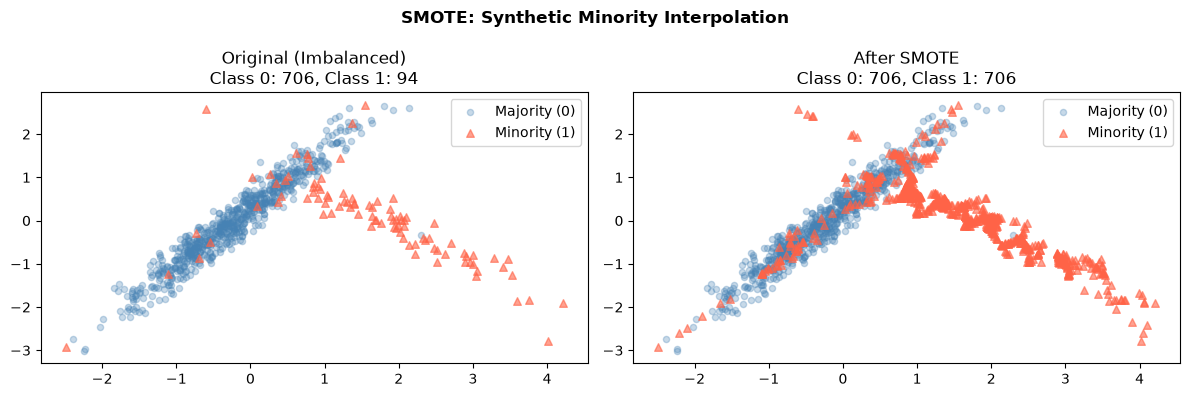

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',  # resample minority to match majority
    k_neighbors=5,             # number of nearest neighbors
    random_state=42
)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)

print('SMOTE')
print(f'  Before: {np.bincount(y_train)}')
print(f'  After:  {np.bincount(y_smote)}')

m = evaluate_classifier(X_smote, X_test_sc, y_smote, y_test, name='SMOTE')
print(f'  F1: {m["f1"]:.4f}, ROC-AUC: {m["roc_auc"]:.4f}, PR-AUC: {m["pr_auc"]:.4f}')

# Visualize SMOTE in 2D
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, X_plot, y_plot, title in zip(
    axes,
    [X_train_sc, X_smote],
    [y_train, y_smote],
    ['Original (Imbalanced)', 'After SMOTE']
):
    ax.scatter(X_plot[y_plot==0, 0], X_plot[y_plot==0, 1],
               label='Majority (0)', alpha=0.3, c='steelblue', s=20)
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1],
               label='Minority (1)', alpha=0.6, c='tomato', s=30, marker='^')
    ax.set_title(f'{title}\nClass 0: {np.sum(y_plot==0)}, Class 1: {np.sum(y_plot==1)}')
    ax.legend()

plt.suptitle('SMOTE: Synthetic Minority Interpolation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 ADASYN Adaptive Synthetic Sampling

**He et al. (2008)** ADASYN adaptively generates more synthetic samples in **harder-to-learn** regions.

**Key idea:** Generate more synthetic samples for minority class instances that are surrounded by many majority class samples (i.e., in denser majority regions).

**Algorithm:**
1. For each minority sample $x_i$, compute $\Delta_i$ = fraction of $k$-nearest neighbors that belong to the majority class
2. Normalize: $\hat{r}_i = \Delta_i / \sum_j \Delta_j$ (a density distribution)
3. Generate $g_i = \hat{r}_i \times G$ synthetic samples for $x_i$ (where $G$ is total to generate)

**Advantages over SMOTE:**
- Focuses on hard borderline cases
- Reduces bias introduced by easy-to-classify samples
- More adaptive to local data distribution

**Limitation:** Can amplify noise by over-sampling noisy minority instances


ADASYN
  Before: [706  94]
  After:  [706 711]
  Note: ADASYN may not produce exact 1:1 ratio (adaptive!)
  F1: 0.4176, ROC-AUC: 0.8806, PR-AUC: 0.7786


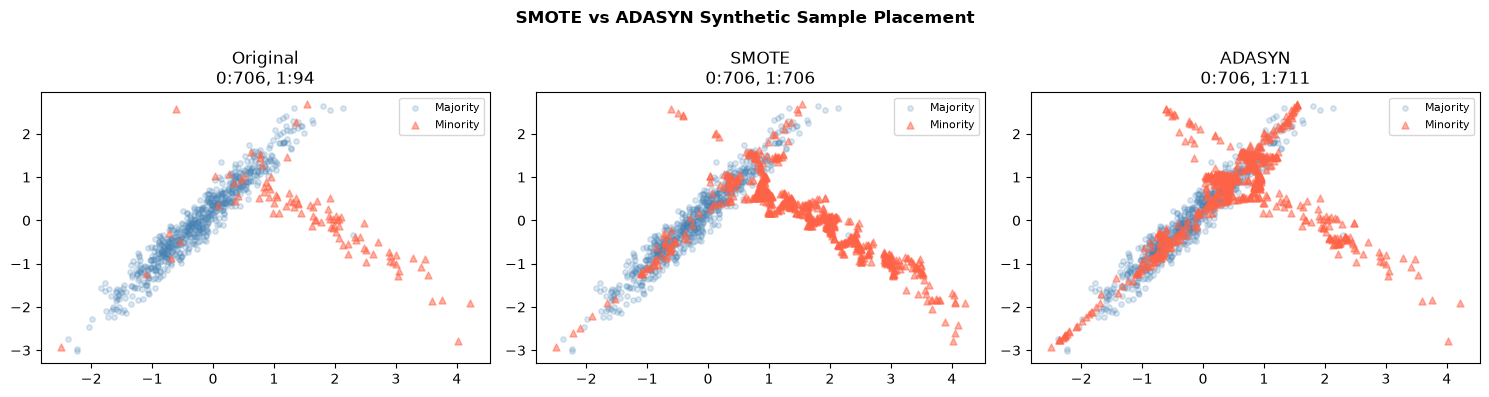

In [6]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(
    sampling_strategy='auto',
    n_neighbors=5,
    random_state=42
)

try:
    X_adasyn, y_adasyn = adasyn.fit_resample(X_train_sc, y_train)
    print('ADASYN')
    print(f'  Before: {np.bincount(y_train)}')
    print(f'  After:  {np.bincount(y_adasyn)}')
    print('  Note: ADASYN may not produce exact 1:1 ratio (adaptive!)')
    m = evaluate_classifier(X_adasyn, X_test_sc, y_adasyn, y_test, name='ADASYN')
    print(f'  F1: {m["f1"]:.4f}, ROC-AUC: {m["roc_auc"]:.4f}, PR-AUC: {m["pr_auc"]:.4f}')
except Exception as e:
    print(f'ADASYN error (may need more minority samples): {e}')

# Compare SMOTE vs ADASYN distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Original', 'SMOTE', 'ADASYN']
datasets = [(X_train_sc, y_train), (X_smote, y_smote)]

try:
    datasets.append((X_adasyn, y_adasyn))
except:
    datasets.append((X_smote, y_smote))

for ax, (X_p, y_p), title in zip(axes, datasets, titles):
    ax.scatter(X_p[y_p==0, 0], X_p[y_p==0, 1], alpha=0.2, c='steelblue', s=15, label='Majority')
    ax.scatter(X_p[y_p==1, 0], X_p[y_p==1, 1], alpha=0.5, c='tomato', s=25, marker='^', label='Minority')
    ax.set_title(f'{title}\n0:{np.sum(y_p==0)}, 1:{np.sum(y_p==1)}')
    ax.legend(fontsize=8)

plt.suptitle('SMOTE vs ADASYN Synthetic Sample Placement', fontweight='bold')
plt.tight_layout()
plt.show()


### 2.4 Borderline-SMOTE (Types 1 and 2)

**Han et al. (2005)** Only generate synthetic samples near the **decision boundary** (borderline samples), not in safe interior regions.

**Borderline sample classification:**
- A minority sample $x_i$ has $m$ nearest neighbors total
- Let $m'$ = number of those neighbors that are majority class
- **Safe:** $m'/m < 0.5$ (mostly surrounded by minority)
- **Borderline (DANGER):** $0.5 \leq m'/m < 1$ (mostly surrounded by majority)
- **Noise:** $m'/m = 1$ (all neighbors are majority, skip)

**Type 1:** Synthetic samples generated using **minority class** neighbors only  
**Type 2:** Synthetic samples can also use **majority class** neighbors (generates samples across boundary)

**Advantage:** More targeted focuses on the hard boundary region  
**Limitation:** Less effective when minority class is highly fragmented


Borderline-SMOTE Type 1
  After resampling: [706 706]
  F1: 0.5195, PR-AUC: 0.3502

Borderline-SMOTE Type 2
  After resampling: [706 706]
  F1: 0.5195, PR-AUC: 0.2892


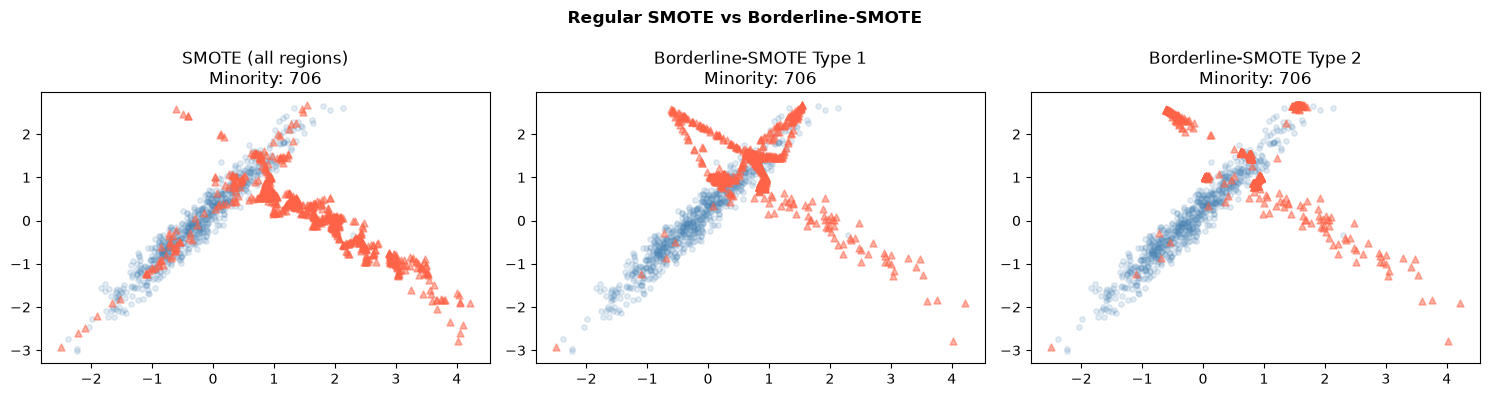

In [7]:
from imblearn.over_sampling import BorderlineSMOTE

# Type 1: generate using minority neighbors only
bsmote1 = BorderlineSMOTE(kind='borderline-1', k_neighbors=5, m_neighbors=10, random_state=42)
X_bsmote1, y_bsmote1 = bsmote1.fit_resample(X_train_sc, y_train)

# Type 2: can also use majority neighbors
bsmote2 = BorderlineSMOTE(kind='borderline-2', k_neighbors=5, m_neighbors=10, random_state=42)
X_bsmote2, y_bsmote2 = bsmote2.fit_resample(X_train_sc, y_train)

print('Borderline-SMOTE Type 1')
print(f'  After resampling: {np.bincount(y_bsmote1)}')
m1 = evaluate_classifier(X_bsmote1, X_test_sc, y_bsmote1, y_test, name='BorderlineSMOTE-1')
print(f'  F1: {m1["f1"]:.4f}, PR-AUC: {m1["pr_auc"]:.4f}')

print('\nBorderline-SMOTE Type 2')
print(f'  After resampling: {np.bincount(y_bsmote2)}')
m2 = evaluate_classifier(X_bsmote2, X_test_sc, y_bsmote2, y_test, name='BorderlineSMOTE-2')
print(f'  F1: {m2["f1"]:.4f}, PR-AUC: {m2["pr_auc"]:.4f}')

# Visual comparison: borderline vs all-region SMOTE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (X_p, y_p), title in zip(
    axes,
    [(X_smote, y_smote), (X_bsmote1, y_bsmote1), (X_bsmote2, y_bsmote2)],
    ['SMOTE (all regions)', 'Borderline-SMOTE Type 1', 'Borderline-SMOTE Type 2']
):
    ax.scatter(X_p[y_p==0, 0], X_p[y_p==0, 1], alpha=0.15, c='steelblue', s=15)
    ax.scatter(X_p[y_p==1, 0], X_p[y_p==1, 1], alpha=0.5, c='tomato', s=25, marker='^')
    ax.set_title(f'{title}\nMinority: {np.sum(y_p==1)}')

plt.suptitle('Regular SMOTE vs Borderline-SMOTE', fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 SMOTE-NC (Nominal + Continuous)

Standard SMOTE works only with **continuous features**. **SMOTE-NC** handles datasets with a mix of continuous and categorical features.

**How it handles categoricals:**
- For continuous features: same interpolation as SMOTE $x_{new} = x_i + \lambda(x_{nn} - x_i)$
- For categorical features: select the **most common category** among the $k$ nearest minority neighbors

**Key parameter:** `categorical_features` list of indices of categorical columns


In [8]:
from imblearn.over_sampling import SMOTENC

# Create a dataset with mixed features (continuous + categorical)
np.random.seed(42)
n_samples = 500
n_minority = 50

# Continuous features
X_cont_maj = np.random.randn(n_samples - n_minority, 3)
X_cont_min = np.random.randn(n_minority, 3) + 1.5

# Categorical features (2 categorical cols)
X_cat_maj = np.random.randint(0, 4, size=(n_samples - n_minority, 2))
X_cat_min = np.random.randint(0, 4, size=(n_minority, 2))

X_mixed = np.hstack([np.vstack([X_cont_maj, X_cont_min]),
                     np.vstack([X_cat_maj, X_cat_min])])
y_mixed = np.array([0]*(n_samples-n_minority) + [1]*n_minority)

print('Mixed dataset shape:', X_mixed.shape)
print('Features: [0,1,2]=continuous, [3,4]=categorical')
print(f'Class distribution: {np.bincount(y_mixed)}')

# SMOTE-NC: specify which features are categorical
smotenc = SMOTENC(
    categorical_features=[3, 4],  # indices of categorical columns
    sampling_strategy='auto',
    k_neighbors=5,
    random_state=42
)
X_smotenc, y_smotenc = smotenc.fit_resample(X_mixed, y_mixed)

print(f'\nAfter SMOTE-NC: {np.bincount(y_smotenc)}')

# Verify categorical values remain valid (integers 0-3)
cat_vals_after = np.unique(X_smotenc[:, 3].astype(int))
print(f'Categorical feature 3 values (should be 0-3): {cat_vals_after}')
print('SMOTE-NC preserves categorical feature validity!')


Mixed dataset shape: (500, 5)
Features: [0,1,2]=continuous, [3,4]=categorical
Class distribution: [450  50]

After SMOTE-NC: [450 450]
Categorical feature 3 values (should be 0-3): [0 1 2 3]
SMOTE-NC preserves categorical feature validity!


### 2.6 SMOTE-SVM

**Nguyen et al. (2011)** Uses an SVM classifier to identify **support vectors** of the minority class, then generates synthetic samples only near those support vectors (which lie near the decision boundary).

**Algorithm:**
1. Train an SVM on the imbalanced data
2. Identify minority class support vectors
3. Apply SMOTE only to those support vectors

**Advantage:** Very targeted generates samples exactly where the classifier is uncertain  
**Limitation:** Computationally expensive (trains an SVM); sensitive to SVM hyperparameters


In [9]:
from imblearn.over_sampling import SVMSMOTE

svmsmote = SVMSMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    m_neighbors=10,
    random_state=42
)

try:
    X_svmsmote, y_svmsmote = svmsmote.fit_resample(X_train_sc, y_train)
    print('SMOTE-SVM')
    print(f'  Before: {np.bincount(y_train)}')
    print(f'  After:  {np.bincount(y_svmsmote)}')
    m = evaluate_classifier(X_svmsmote, X_test_sc, y_svmsmote, y_test, name='SMOTE-SVM')
    print(f'  F1: {m["f1"]:.4f}, ROC-AUC: {m["roc_auc"]:.4f}, PR-AUC: {m["pr_auc"]:.4f}')
except Exception as e:
    print(f'SMOTE-SVM: {e}')
    X_svmsmote, y_svmsmote = X_smote, y_smote
    print('Falling back to SMOTE results for comparison')


SMOTE-SVM
  Before: [706  94]
  After:  [706 706]
  F1: 0.5000, ROC-AUC: 0.8777, PR-AUC: 0.6746


## 3. Undersampling Techniques

Undersampling **reduces** the majority class to balance the dataset.

**Pros:** Faster training; can remove noisy/redundant samples  
**Cons:** Loss of potentially useful majority class information

**Rule of thumb:** Prefer undersampling when majority class is very large (millions of samples) and random undersampling shows no significant performance drop.


In [10]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_sc, y_train)

print('Random Undersampling')
print(f'  Before: {np.bincount(y_train)}')
print(f'  After:  {np.bincount(y_rus)}')

m = evaluate_classifier(X_rus, X_test_sc, y_rus, y_test, name='RandomUnderSampler')
print(f'  F1: {m["f1"]:.4f}, ROC-AUC: {m["roc_auc"]:.4f}, PR-AUC: {m["pr_auc"]:.4f}')


Random Undersampling
  Before: [706  94]
  After:  [94 94]
  F1: 0.6667, ROC-AUC: 0.8624, PR-AUC: 0.8031


### 3.2 NearMiss (Versions 1, 2, 3)

NearMiss selects majority class samples based on their **distance to minority class samples**.

**Version 1:** Select majority samples whose **average distance to the $k$ nearest minority samples is smallest**  
→ Keeps majority samples closest to the minority class

**Version 2:** Select majority samples whose **average distance to the $k$ farthest minority samples is smallest**  
→ Keeps majority samples that are far from all minority clusters but close to some

**Version 3:** For each minority sample, keep the $m$ nearest majority samples  
→ Guarantees each minority sample has some close majority neighbors (2-step: first keep $m$-closest majority for each minority, then further filter)

| Version | Distance Criterion | Effect |
|---------|-------------------|--------|
| NearMiss-1 | Avg to $k$ nearest minority | Keeps majority near minority clusters |
| NearMiss-2 | Avg to $k$ farthest minority | Keeps majority that broadly covers minority space |
| NearMiss-3 | Per-minority-sample nearest | Ensures local coverage around each minority point |


NearMiss-1: After=[94 94], F1=0.5455, PR-AUC=0.7817
NearMiss-2: After=[94 94], F1=0.5000, PR-AUC=0.6656
NearMiss-3: After=[75 94], F1=0.8500, PR-AUC=0.8005


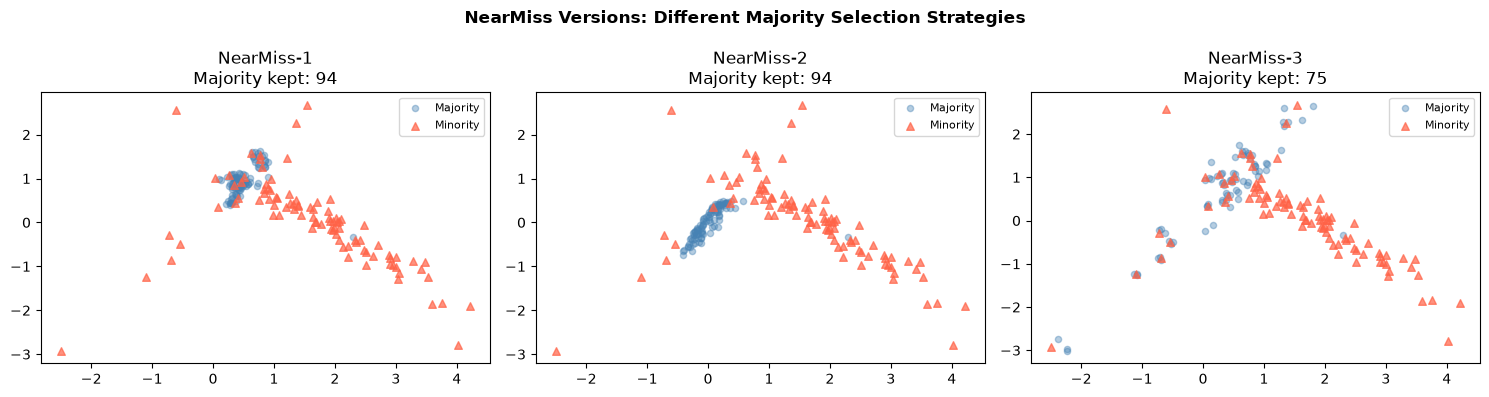

In [11]:
from imblearn.under_sampling import NearMiss

results_nm = {}
for v in [1, 2, 3]:
    nm = NearMiss(version=v, n_neighbors=3)
    X_nm, y_nm = nm.fit_resample(X_train_sc, y_train)
    m = evaluate_classifier(X_nm, X_test_sc, y_nm, y_test, name=f'NearMiss-{v}')
    results_nm[v] = (X_nm, y_nm, m)
    print(f'NearMiss-{v}: After={np.bincount(y_nm)}, F1={m["f1"]:.4f}, PR-AUC={m["pr_auc"]:.4f}')

# Visualize all three versions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (v, (X_p, y_p, _)) in zip(axes, results_nm.items()):
    ax.scatter(X_p[y_p==0, 0], X_p[y_p==0, 1], alpha=0.4, c='steelblue', s=20, label='Majority')
    ax.scatter(X_p[y_p==1, 0], X_p[y_p==1, 1], alpha=0.7, c='tomato', s=30, marker='^', label='Minority')
    ax.set_title(f'NearMiss-{v}\nMajority kept: {np.sum(y_p==0)}')
    ax.legend(fontsize=8)

plt.suptitle('NearMiss Versions: Different Majority Selection Strategies', fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Tomek Links

**Tomek (1976)** A Tomek link is a pair $(x_i, x_j)$ where:
- $x_i$ and $x_j$ belong to **different classes**
- There is **no sample $x_k$** such that $d(x_k, x_i) < d(x_j, x_i)$ or $d(x_k, x_j) < d(x_i, x_j)$
  (i.e., they are mutual nearest neighbors across class boundary)

**Action:** Remove the **majority class** sample from each Tomek link pair (optionally both).

**Effect:** Cleans the boundary region by removing ambiguous majority samples right next to the minority class. Usually results in mild undersampling (only removes borderline noise).

**Use case:** Often used as a **cleaning step** after oversampling (e.g., SMOTE-Tomek).


In [12]:
from imblearn.under_sampling import TomekLinks

tomek = TomekLinks(sampling_strategy='majority')  # only remove majority from Tomek links
X_tomek, y_tomek = tomek.fit_resample(X_train_sc, y_train)

n_removed = len(y_train) - len(y_tomek)
print('Tomek Links')
print(f'  Before: {np.bincount(y_train)}')
print(f'  After:  {np.bincount(y_tomek)}')
print(f'  Removed {n_removed} Tomek link samples from majority class')

m = evaluate_classifier(X_tomek, X_test_sc, y_tomek, y_test, name='TomekLinks')
print(f'  F1: {m["f1"]:.4f}, ROC-AUC: {m["roc_auc"]:.4f}')
print('  Note: Tomek Links is primarily a cleaning technique, not heavy undersampling')


Tomek Links
  Before: [706  94]
  After:  [693  94]
  Removed 13 Tomek link samples from majority class
  F1: 0.8205, ROC-AUC: 0.8617
  Note: Tomek Links is primarily a cleaning technique, not heavy undersampling


### 3.4-3.6 Edited Nearest Neighbors (ENN), Repeated ENN, and All-KNN

These methods remove samples that are **misclassified by their nearest neighbors**.

**ENN (Wilson, 1972):**
- For each sample, check if it agrees with a majority vote of its $k$ nearest neighbors
- Remove samples that are **misclassified** (disagreement)
- Applied to majority class (or both classes)

**Repeated ENN:**  
- Apply ENN repeatedly until no more samples are removed or max iterations reached
- Results in more aggressive cleaning than a single pass

**All-KNN:**  
- Apply ENN with increasing $k$ from $1$ to $k_{max}$
- A sample must survive ALL $k$ iterations to be kept
- Most conservative removes samples that are borderline at any neighborhood size


In [13]:
from imblearn.under_sampling import (
    EditedNearestNeighbours,
    RepeatedEditedNearestNeighbours,
    AllKNN
)

# ENN
enn = EditedNearestNeighbours(n_neighbors=3, kind_sel='all')
X_enn, y_enn = enn.fit_resample(X_train_sc, y_train)

# Repeated ENN
renn = RepeatedEditedNearestNeighbours(n_neighbors=3, max_iter=100)
X_renn, y_renn = renn.fit_resample(X_train_sc, y_train)

# All-KNN
allknn = AllKNN(n_neighbors=3, kind_sel='all')
X_allknn, y_allknn = allknn.fit_resample(X_train_sc, y_train)

print('Cleaning Methods Comparison:')
print(f'Original:       {np.bincount(y_train)} (total={len(y_train)})')
print(f'ENN:            {np.bincount(y_enn)} (total={len(y_enn)})')
print(f'Repeated ENN:   {np.bincount(y_renn)} (total={len(y_renn)})')
print(f'All-KNN:        {np.bincount(y_allknn)} (total={len(y_allknn)})')

print('\nMetrics:')
for X_p, y_p, name in [
    (X_enn, y_enn, 'ENN'),
    (X_renn, y_renn, 'RepeatedENN'),
    (X_allknn, y_allknn, 'AllKNN')
]:
    m = evaluate_classifier(X_p, X_test_sc, y_p, y_test, name=name)
    print(f'  {name:<15} F1={m["f1"]:.4f}, PR-AUC={m["pr_auc"]:.4f}')


Cleaning Methods Comparison:
Original:       [706  94] (total=800)
ENN:            [645  94] (total=739)
Repeated ENN:   [619  94] (total=713)
All-KNN:        [633  94] (total=727)

Metrics:
  ENN             F1=0.8205, PR-AUC=0.8029
  RepeatedENN     F1=0.8205, PR-AUC=0.8023
  AllKNN          F1=0.8205, PR-AUC=0.8026


### 3.7-3.8 Neighbourhood Cleaning Rule & One-Sided Selection

**Neighbourhood Cleaning Rule (NCR) Laurikkala (2001):**
- Combine ENN with a per-class threshold
- Remove noisy/borderline majority samples using 3-NN
- Also removes minority samples that are misclassified AND whose neighborhood is dominated by majority
- More aggressive than plain ENN toward borderline minority noise

**One-Sided Selection (OSS) Kubat & Matwin (1997):**  
Two-step procedure:
1. Apply **Tomek Links** to remove borderline majority samples
2. Apply **CNN (Condensed Nearest Neighbor)** to further remove redundant interior majority samples

Result: keeps only **borderline** and **remote** majority samples (a minimal consistent subset).


In [14]:
from imblearn.under_sampling import NeighbourhoodCleaningRule, OneSidedSelection

ncr = NeighbourhoodCleaningRule(n_neighbors=3, threshold_cleaning=0.5)
X_ncr, y_ncr = ncr.fit_resample(X_train_sc, y_train)

oss = OneSidedSelection(n_neighbors=1, n_seeds_S=1, random_state=42)
X_oss, y_oss = oss.fit_resample(X_train_sc, y_train)

print('Advanced Cleaning Methods:')
print(f'Original:   {np.bincount(y_train)}')
print(f'NCR:        {np.bincount(y_ncr)}')
print(f'OSS:        {np.bincount(y_oss)}')

for X_p, y_p, name in [(X_ncr, y_ncr, 'NCR'), (X_oss, y_oss, 'OSS')]:
    m = evaluate_classifier(X_p, X_test_sc, y_p, y_test, name=name)
    print(f'  {name}: F1={m["f1"]:.4f}, PR-AUC={m["pr_auc"]:.4f}')


Advanced Cleaning Methods:
Original:   [706  94]
NCR:        [644  94]
OSS:        [581  94]
  NCR: F1=0.8205, PR-AUC=0.8026
  OSS: F1=0.8205, PR-AUC=0.8015


### 3.9-3.10 Cluster Centroids & Instance Hardness Threshold

**Cluster Centroids:**
- Use k-means clustering on the **majority class**
- Replace each cluster with its **centroid** (synthetic representative)
- Unlike other methods, generates new points (doesn't just select existing ones)
- Preserves the overall distribution shape of the majority class

**Instance Hardness Threshold (IHT) Smith et al. (2014):**
- Train a classifier on the full dataset
- Remove samples with **low predicted probability** for their true class
- "Hard" instances (near decision boundary) are pruned
- Removes both hard minority AND majority instances, but primarily affects majority class in imbalanced settings


In [15]:
from imblearn.under_sampling import ClusterCentroids, InstanceHardnessThreshold

# Cluster Centroids
cc = ClusterCentroids(sampling_strategy='auto', random_state=42)
try:
    X_cc, y_cc = cc.fit_resample(X_train_sc, y_train)
    print(f'Cluster Centroids: {np.bincount(y_cc)}')
    m_cc = evaluate_classifier(X_cc, X_test_sc, y_cc, y_test)
    print(f'  F1={m_cc["f1"]:.4f}, PR-AUC={m_cc["pr_auc"]:.4f}')
except Exception as e:
    print(f'Cluster Centroids: {e}')

# Instance Hardness Threshold
iht = InstanceHardnessThreshold(
    estimator=RandomForestClassifier(n_estimators=10, random_state=42),
    sampling_strategy='auto',
    cv=3,
    random_state=42
)
try:
    X_iht, y_iht = iht.fit_resample(X_train_sc, y_train)
    print(f'\nInstance Hardness Threshold: {np.bincount(y_iht)}')
    m_iht = evaluate_classifier(X_iht, X_test_sc, y_iht, y_test)
    print(f'  F1={m_iht["f1"]:.4f}, PR-AUC={m_iht["pr_auc"]:.4f}')
except Exception as e:
    print(f'Instance Hardness Threshold: {e}')


Cluster Centroids: [94 94]
  F1=0.7727, PR-AUC=0.8025



Instance Hardness Threshold: [587  94]
  F1=0.8205, PR-AUC=0.8024


## 4. Combined Methods

Combined methods apply **both oversampling and undersampling** in sequence to get the benefits of both:
- Oversample the minority class to add diversity
- Then clean up the boundary region to remove noise and overlap

### 4.1 SMOTE-Tomek

**Pipeline:**
1. Apply SMOTE to oversample minority class
2. Apply Tomek Links to clean boundary remove Tomek link pairs (majority side)

**Effect:** Creates a cleaner boundary with synthetic minority samples, then removes the majority overlap.

### 4.2 SMOTE-ENN

**Pipeline:**
1. Apply SMOTE to oversample minority class
2. Apply ENN to clean misclassified samples from both classes

**Effect:** More aggressive cleaning than SMOTE-Tomek; removes more samples but results in cleaner boundaries.


Combined Methods:
Original:    [706  94] (total=800)
SMOTE-Tomek: [662 662] (total=1324)
SMOTE-ENN:   [506 576] (total=1082)



SMOTE-Tomek: F1=0.6939, ROC-AUC=0.8612, PR-AUC=0.8028
SMOTE-ENN:   F1=0.6667, ROC-AUC=0.8674, PR-AUC=0.8031


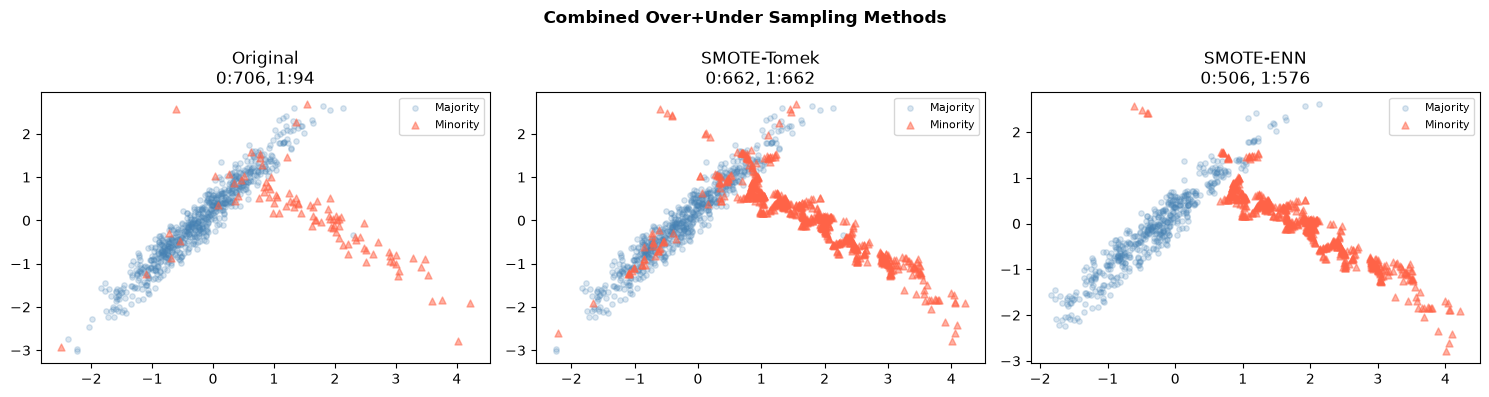

In [16]:
from imblearn.combine import SMOTETomek, SMOTEENN

# SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_st, y_st = smote_tomek.fit_resample(X_train_sc, y_train)

# SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_se, y_se = smote_enn.fit_resample(X_train_sc, y_train)

print('Combined Methods:')
print(f'Original:    {np.bincount(y_train)} (total={len(y_train)})')
print(f'SMOTE-Tomek: {np.bincount(y_st)} (total={len(y_st)})')
print(f'SMOTE-ENN:   {np.bincount(y_se)} (total={len(y_se)})')

m_st = evaluate_classifier(X_st, X_test_sc, y_st, y_test, name='SMOTE-Tomek')
m_se = evaluate_classifier(X_se, X_test_sc, y_se, y_test, name='SMOTE-ENN')

print(f'\nSMOTE-Tomek: F1={m_st["f1"]:.4f}, ROC-AUC={m_st["roc_auc"]:.4f}, PR-AUC={m_st["pr_auc"]:.4f}')
print(f'SMOTE-ENN:   F1={m_se["f1"]:.4f}, ROC-AUC={m_se["roc_auc"]:.4f}, PR-AUC={m_se["pr_auc"]:.4f}')

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (X_p, y_p), title in zip(
    axes,
    [(X_train_sc, y_train), (X_st, y_st), (X_se, y_se)],
    ['Original', 'SMOTE-Tomek', 'SMOTE-ENN']
):
    ax.scatter(X_p[y_p==0, 0], X_p[y_p==0, 1], alpha=0.2, c='steelblue', s=15, label='Majority')
    ax.scatter(X_p[y_p==1, 0], X_p[y_p==1, 1], alpha=0.5, c='tomato', s=25, marker='^', label='Minority')
    ax.set_title(f'{title}\n0:{np.sum(y_p==0)}, 1:{np.sum(y_p==1)}')
    ax.legend(fontsize=8)

plt.suptitle('Combined Over+Under Sampling Methods', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Ensemble Approaches

Ensemble methods integrate **resampling directly into the ensemble learning process**, often outperforming separate resampling + classification pipelines.

### 5.1 BalancedBaggingClassifier

A modified Bagging classifier where each base estimator is trained on a **randomly undersampled bootstrap sample**. Combines the benefits of bagging (variance reduction) with balanced training.

### 5.2 BalancedRandomForestClassifier

Like Random Forest, but each tree is grown on a **balanced bootstrap sample** (random undersampling of majority class per tree). Often outperforms SMOTE + Random Forest in practice.

### 5.3 EasyEnsemble

**Liu et al. (2009)** Creates multiple balanced subsets by **random undersampling** of the majority class, trains an AdaBoost classifier on each, and combines predictions.

### 5.4 RUSBoost

**Seiffert et al. (2010)** Combines **Random Undersampling (RUS)** with **AdaBoost**. At each boosting round, randomly undersample the majority class before training the weak learner. Simpler than EasyEnsemble but often competitive.


BalancedBagging: F1=0.7660, ROC-AUC=0.9043, PR-AUC=0.8272


BalancedRandomForest: F1=0.7500, ROC-AUC=0.9043, PR-AUC=0.8309


EasyEnsemble: F1=0.6667, ROC-AUC=0.8330, PR-AUC=0.7706
RUSBoost: F1=0.6182, ROC-AUC=0.8051, PR-AUC=0.7544


RandomForest (baseline): F1=0.8095, ROC-AUC=0.9058, PR-AUC=0.8350


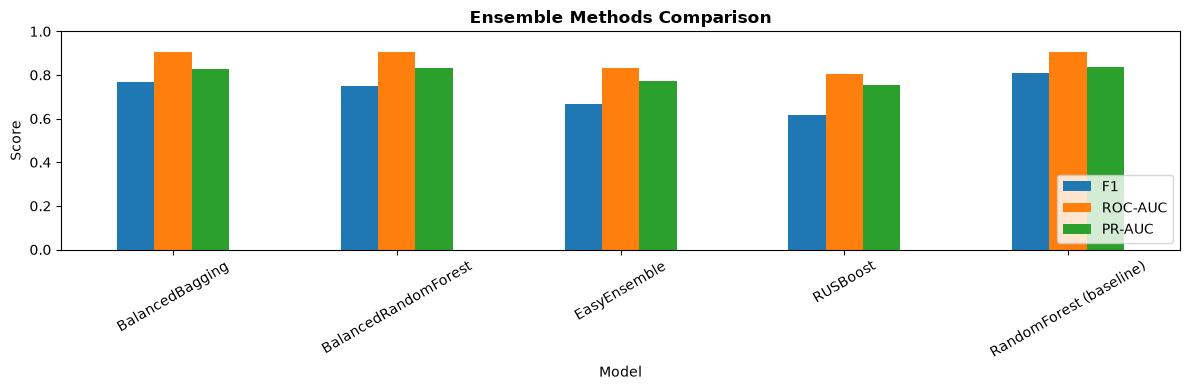

In [17]:
from imblearn.ensemble import (
    BalancedBaggingClassifier,
    BalancedRandomForestClassifier,
    EasyEnsembleClassifier,
    RUSBoostClassifier
)

ensemble_models = [
    ('BalancedBagging', BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50, random_state=42
    )),
    ('BalancedRandomForest', BalancedRandomForestClassifier(
        n_estimators=100, random_state=42
    )),
    ('EasyEnsemble', EasyEnsembleClassifier(
        n_estimators=10, random_state=42
    )),
    ('RUSBoost', RUSBoostClassifier(
        n_estimators=50, random_state=42
    )),
    # Baseline
    ('RandomForest (baseline)', RandomForestClassifier(
        n_estimators=100, random_state=42
    )),
]

ensemble_results = []
for name, model in ensemble_models:
    try:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        result = {
            'Model': name,
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob),
            'PR-AUC': average_precision_score(y_test, y_prob),
        }
        ensemble_results.append(result)
        print(f'{name}: F1={result["F1"]:.4f}, ROC-AUC={result["ROC-AUC"]:.4f}, PR-AUC={result["PR-AUC"]:.4f}')
    except Exception as e:
        print(f'{name}: Error - {e}')

# Plot comparison
if ensemble_results:
    df_ens = pd.DataFrame(ensemble_results).set_index('Model')
    df_ens[['F1', 'ROC-AUC', 'PR-AUC']].plot(kind='bar', figsize=(12, 4), rot=30)
    plt.title('Ensemble Methods Comparison', fontsize=12, fontweight='bold')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


## 6. When to Use Which Technique

| Situation | Recommended Approach |
|-----------|---------------------|
| Large dataset, mild imbalance (5:1 to 10:1) | SMOTE or Borderline-SMOTE |
| Severe imbalance (>100:1) | EasyEnsemble, BalancedRandomForest, or SMOTE-ENN |
| Very large majority class (millions) | Random Undersampling or NearMiss |
| Mixed categorical + continuous | SMOTE-NC |
| Noisy boundary region | SMOTE-Tomek or SMOTE-ENN |
| High-dimensional sparse data (text/NLP) | Class weights, avoid SMOTE |
| Need interpretable model | Cost-sensitive learning (class_weight) |
| Real-time streaming | Random Oversampling (no KNN computation) |
| Multiclass imbalance | OVO/OVA + SMOTE per class pair |
| Small dataset | SMOTE (avoid undersampling too little data) |

### Decision Guide

```
Start: Is your dataset large? (>100k samples)
├── Yes → Try Random Undersampling first (fast)
│         If performance poor → SMOTE or Ensemble
└── No  → Is imbalance severe? (>50:1)
           ├── Yes → EasyEnsemble, BalancedRandomForest
           └── No  → SMOTE or SMOTE-ENN
```

> **Best practice:** Always use **stratified train/test split** and evaluate with **PR-AUC or F1** rather than accuracy.


                        f1  roc_auc  pr_auc  recall  precision  size
name                                                                
No Resampling       0.8205   0.8615  0.8024  0.6957     1.0000   800
Random Oversample   0.6939   0.8612  0.8024  0.7391     0.6538  1412
SMOTE               0.6800   0.8617  0.8025  0.7391     0.6296  1412
Borderline-SMOTE-1  0.5195   0.8369  0.3502  0.8696     0.3704  1412
Random Undersample  0.6667   0.8624  0.8031  0.7391     0.6071   188
NearMiss-1          0.5455   0.8349  0.7817  0.7826     0.4186   188
Tomek Links         0.8205   0.8617  0.8028  0.6957     1.0000   787
ENN                 0.8205   0.8620  0.8029  0.6957     1.0000   739
SMOTE-Tomek         0.6939   0.8612  0.8028  0.7391     0.6538  1324
SMOTE-ENN           0.6667   0.8674  0.8031  0.7391     0.6071  1082


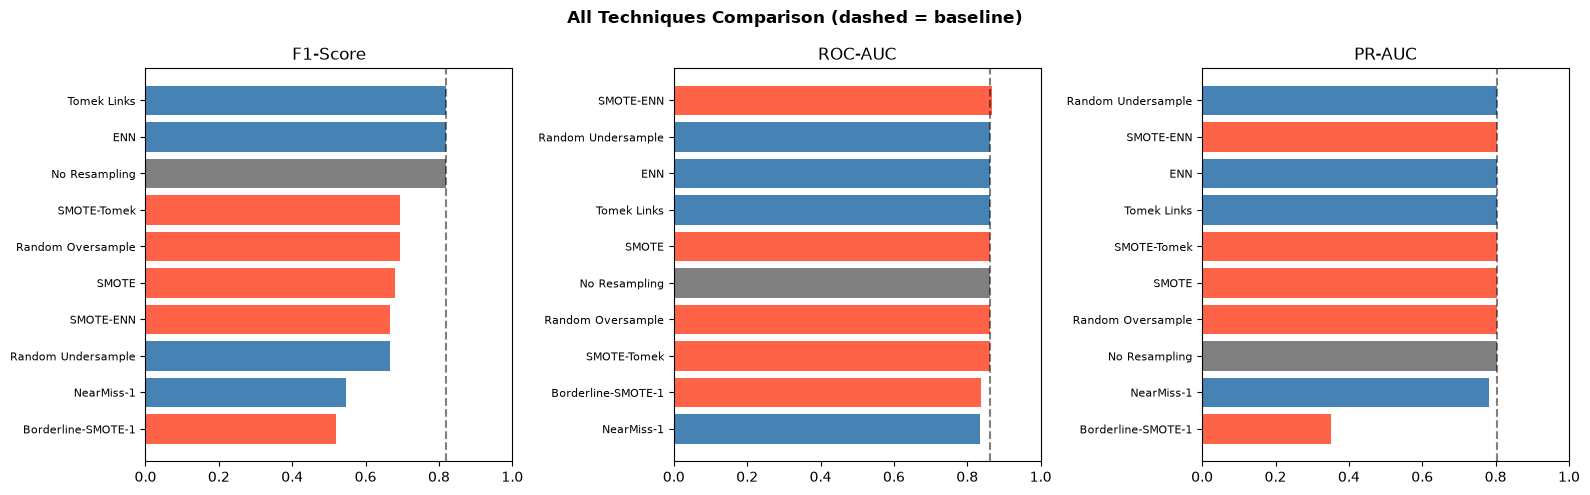

In [18]:
# Comprehensive technique comparison on the demo dataset

techniques = [
    ('No Resampling', X_train_sc, y_train),
    ('Random Oversample', X_ros, y_ros),
    ('SMOTE', X_smote, y_smote),
    ('Borderline-SMOTE-1', X_bsmote1, y_bsmote1),
    ('Random Undersample', X_rus, y_rus),
    ('NearMiss-1', *results_nm[1][:2]),
    ('Tomek Links', X_tomek, y_tomek),
    ('ENN', X_enn, y_enn),
    ('SMOTE-Tomek', X_st, y_st),
    ('SMOTE-ENN', X_se, y_se),
]

comparison_results = []
for name, X_tr, y_tr in techniques:
    m = evaluate_classifier(X_tr, X_test_sc, y_tr, y_test, name=name)
    m['size'] = len(y_tr)
    comparison_results.append(m)

df_comp = pd.DataFrame(comparison_results).set_index('name')
print(df_comp[['f1', 'roc_auc', 'pr_auc', 'recall', 'precision', 'size']].round(4).to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes, ['f1', 'roc_auc', 'pr_auc'], ['F1-Score', 'ROC-AUC', 'PR-AUC']):
    vals = df_comp[col].sort_values(ascending=True)
    colors = ['tomato' if 'SMOTE' in i or 'Random Over' in i else
              'steelblue' if 'Under' in i or 'NearMiss' in i or 'Tomek' in i or 'ENN' in i else
              'gray' for i in vals.index]
    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=8)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.axvline(df_comp.loc['No Resampling', col], color='black', linestyle='--', alpha=0.5)

plt.suptitle('All Techniques Comparison (dashed = baseline)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Cost-Sensitive Learning

Instead of resampling, we can **adjust the learning algorithm** to penalize misclassification of the minority class more heavily.

### The `class_weight` Parameter

Most scikit-learn classifiers accept `class_weight`:
- `class_weight='balanced'`: Automatically weights inversely proportional to class frequency
  $$w_i = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples}_i}}$$
- `class_weight={0: 1, 1: 10}`: Manually set weights

### Advantages
- No data modification needed
- Works natively with high-dimensional data (text, sparse)
- Simple and fast no preprocessing step
- Directly optimizes the loss function with class-aware penalties

### When to Use
- Logistic Regression, SVM, Decision Trees, Random Forests all support it
- Neural networks: use `sample_weight` in `fit()` or `class_weight` in Keras
- **Often the first thing to try** before more complex resampling approaches


In [19]:
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights
class_weights_balanced = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
print(f'Balanced class weights: {dict(zip(np.unique(y_train), class_weights_balanced))}')

# Compare different cost-sensitive approaches
cost_models = [
    ('LR (no weight)', LogisticRegression(random_state=42, max_iter=1000)),
    ('LR (balanced)', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)),
    ('LR (custom 1:10)', LogisticRegression(class_weight={0:1, 1:10}, random_state=42, max_iter=1000)),
    ('RF (no weight)', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('RF (balanced)', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('RF (balanced subsample)', RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=42)),
]

print('\nCost-Sensitive Learning Results:')
print(f'{"Model":<30} {"F1":>8} {"Recall":>8} {"Precision":>10} {"ROC-AUC":>10} {"PR-AUC":>8}')
print('-' * 80)
cost_results = []
for name, model in cost_models:
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    result = {
        'Model': name,
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
    }
    cost_results.append(result)
    print(f'{name:<30} {result["F1"]:>8.4f} {result["Recall"]:>8.4f} {result["Precision"]:>10.4f} {result["ROC-AUC"]:>10.4f} {result["PR-AUC"]:>8.4f}')

# Threshold tuning
print('\n--- Threshold Tuning ---')
lr_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_balanced.fit(X_train_sc, y_train)
y_prob = lr_balanced.predict_proba(X_test_sc)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    print(f'  Threshold={threshold}: F1={f1:.4f}, Recall={rec:.4f}, Precision={prec:.4f}')


Balanced class weights: {np.int64(0): np.float64(0.56657223796034), np.int64(1): np.float64(4.25531914893617)}

Cost-Sensitive Learning Results:
Model                                F1   Recall  Precision    ROC-AUC   PR-AUC
--------------------------------------------------------------------------------
LR (no weight)                   0.8205   0.6957     1.0000     0.8615   0.8024
LR (balanced)                    0.6538   0.7391     0.5862     0.8612   0.8025
LR (custom 1:10)                 0.5965   0.7391     0.5000     0.8610   0.8026


RF (no weight)                   0.8095   0.7391     0.8947     0.9058   0.8350


RF (balanced)                    0.7660   0.7826     0.7500     0.9162   0.8353


RF (balanced subsample)          0.8095   0.7391     0.8947     0.9073   0.8325

--- Threshold Tuning ---
  Threshold=0.3: F1=0.4750, Recall=0.8261, Precision=0.3333
  Threshold=0.4: F1=0.5484, Recall=0.7391, Precision=0.4359
  Threshold=0.5: F1=0.6538, Recall=0.7391, Precision=0.5862
  Threshold=0.6: F1=0.7727, Recall=0.7391, Precision=0.8095


## 8. End-to-End Fraud Detection Example

A complete pipeline simulating a real fraud detection scenario:
- Highly imbalanced dataset (0.17% fraud rate, like the Kaggle Credit Card Fraud dataset)
- Feature engineering
- Multiple resampling strategies
- Model evaluation with proper metrics
- Final model selection


In [20]:
# Simulate a fraud detection dataset
np.random.seed(42)

n_legit = 10000
n_fraud = 50  # ~0.5% fraud rate

# Legitimate transactions
X_legit = np.random.randn(n_legit, 8)
X_legit[:, 0] = np.abs(X_legit[:, 0]) * 100  # transaction amount
X_legit[:, 1] = np.random.uniform(0, 24, n_legit)  # hour of day
X_legit[:, 2] = np.random.randint(0, 5, n_legit)   # merchant category

# Fraud transactions (different distribution)
X_fraud = np.random.randn(n_fraud, 8) * 1.5 + 2
X_fraud[:, 0] = np.abs(X_fraud[:, 0]) * 300 + 500  # higher amounts
X_fraud[:, 1] = np.random.uniform(0, 6, n_fraud)    # late night transactions
X_fraud[:, 2] = np.random.randint(3, 8, n_fraud)    # different merchant categories

X_fraud_full = np.concatenate([X_legit, X_fraud], axis=0)
y_fraud_full = np.array([0]*n_legit + [1]*n_fraud)

# Shuffle
idx = np.random.permutation(len(y_fraud_full))
X_fraud_full, y_fraud_full = X_fraud_full[idx], y_fraud_full[idx]

feature_names = ['Amount', 'Hour', 'MerchantCat', 'V1', 'V2', 'V3', 'V4', 'V5']
df_fraud = pd.DataFrame(X_fraud_full, columns=feature_names)
df_fraud['label'] = y_fraud_full

print('Fraud Detection Dataset')
print(f'  Total transactions: {len(y_fraud_full):,}')
print(f'  Legitimate: {np.sum(y_fraud_full==0):,} ({np.mean(y_fraud_full==0)*100:.1f}%)')
print(f'  Fraudulent: {np.sum(y_fraud_full==1):,} ({np.mean(y_fraud_full==1)*100:.2f}%)')
print(f'  Imbalance ratio: {np.sum(y_fraud_full==0)/np.sum(y_fraud_full==1):.0f}:1')
df_fraud.describe()


Fraud Detection Dataset
  Total transactions: 10,050
  Legitimate: 10,000 (99.5%)
  Fraudulent: 50 (0.50%)
  Imbalance ratio: 200:1


,Amount,Hour,MerchantCat,V1,V2,V3,V4,V5,label
count,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000
mean,85.144131,11.982583,2.014826,0.011061,0.014972,0.008482,0.016913,0.010081,0.004975
std,102.412519,6.935568,1.427478,1.014665,1.013653,1.011669,1.012083,1.011704,0.070362
min,0.012305,0.002350,0.000000,-3.688365,-3.419906,-4.465604,-3.655087,-4.157734,0.000000
25%,31.464173,5.852419,1.000000,-0.678763,-0.658449,-0.684391,-0.663936,-0.677228,0.000000
50%,67.830521,12.006487,2.000000,0.008892,0.019650,0.007412,0.008080,0.006709,0.000000
75%,115.744006,18.016694,3.000000,0.693507,0.687095,0.685796,0.705494,0.672011,0.000000
max,2588.356281,23.994610,7.000000,4.976203,4.920356,6.343831,5.368641,5.574892,1.000000


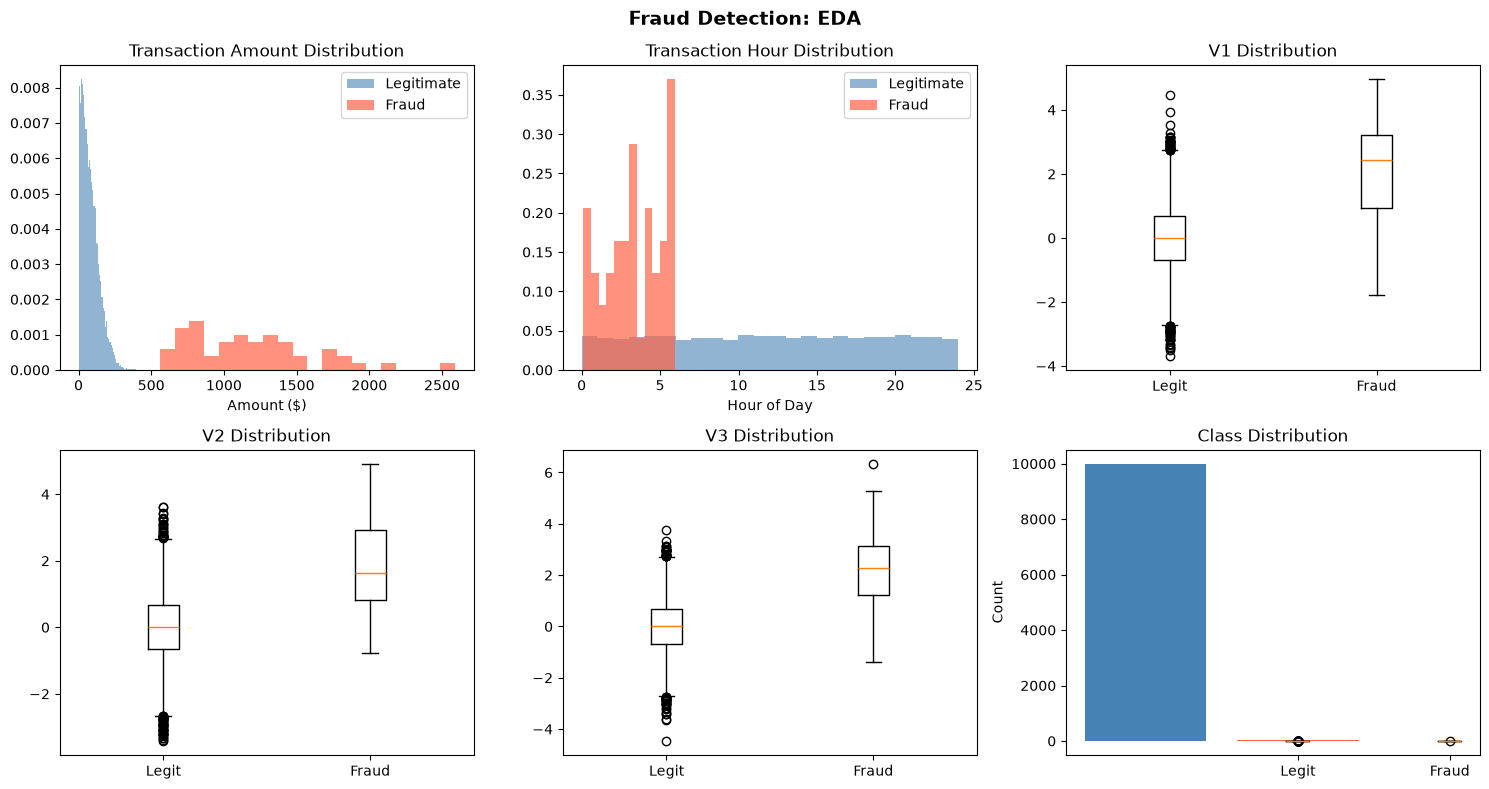

In [21]:
# EDA: Visualize fraud vs legitimate patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

legit = df_fraud[df_fraud['label']==0]
fraud = df_fraud[df_fraud['label']==1]

# Amount distribution
axes[0,0].hist(legit['Amount'], bins=50, alpha=0.6, label='Legitimate', color='steelblue', density=True)
axes[0,0].hist(fraud['Amount'], bins=20, alpha=0.7, label='Fraud', color='tomato', density=True)
axes[0,0].set_title('Transaction Amount Distribution')
axes[0,0].legend()
axes[0,0].set_xlabel('Amount ($)')

# Hour distribution
axes[0,1].hist(legit['Hour'], bins=24, alpha=0.6, label='Legitimate', color='steelblue', density=True)
axes[0,1].hist(fraud['Hour'], bins=12, alpha=0.7, label='Fraud', color='tomato', density=True)
axes[0,1].set_title('Transaction Hour Distribution')
axes[0,1].legend()
axes[0,1].set_xlabel('Hour of Day')

# Feature distributions
for ax, feature in zip(axes[0,2:].tolist() + axes[1,:].tolist(), ['V1', 'V2', 'V3', 'V4']):
    ax.boxplot([legit[feature], fraud[feature]], tick_labels=['Legit', 'Fraud'])
    ax.set_title(f'{feature} Distribution')

# Class balance
axes[1,2].bar(['Legitimate', 'Fraud'], [n_legit, n_fraud], color=['steelblue', 'tomato'])
axes[1,2].set_title('Class Distribution')
axes[1,2].set_ylabel('Count')

plt.suptitle('Fraud Detection: EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [22]:
# Full fraud detection pipeline with multiple strategies

# Train/test split (stratified!)
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_fraud_full, y_fraud_full,
    test_size=0.2, stratify=y_fraud_full, random_state=42
)

# Scale
scaler_f = StandardScaler()
X_f_train_sc = scaler_f.fit_transform(X_f_train)
X_f_test_sc = scaler_f.transform(X_f_test)

print(f'Train: {np.bincount(y_f_train)}, Test: {np.bincount(y_f_test)}')

# Define strategies
fraud_strategies = [
    ('Baseline (no resampling)', None, None),
    ('Class Weight balanced', None, {'class_weight': 'balanced'}),
    ('SMOTE', SMOTE(random_state=42), None),
    ('ADASYN', ADASYN(random_state=42), None),
    ('SMOTE-Tomek', SMOTETomek(random_state=42), None),
    ('SMOTE-ENN', SMOTEENN(random_state=42), None),
    ('Random Undersample', RandomUnderSampler(random_state=42), None),
    ('Balanced RF', None, '_balanced_rf'),
    ('EasyEnsemble', None, '_easy_ensemble'),
]

fraud_results = []

for name, resampler, clf_kwargs in fraud_strategies:
    try:
        if clf_kwargs == '_balanced_rf':
            model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
            model.fit(X_f_train_sc, y_f_train)
        elif clf_kwargs == '_easy_ensemble':
            model = EasyEnsembleClassifier(n_estimators=10, random_state=42)
            model.fit(X_f_train_sc, y_f_train)
        else:
            kw = clf_kwargs or {}
            model = RandomForestClassifier(n_estimators=100, random_state=42, **kw)
            if resampler:
                X_tr, y_tr = resampler.fit_resample(X_f_train_sc, y_f_train)
            else:
                X_tr, y_tr = X_f_train_sc, y_f_train
            model.fit(X_tr, y_tr)

        y_pred = model.predict(X_f_test_sc)
        y_prob = model.predict_proba(X_f_test_sc)[:, 1]

        result = {
            'Strategy': name,
            'F1': f1_score(y_f_test, y_pred, zero_division=0),
            'Recall': recall_score(y_f_test, y_pred, zero_division=0),
            'Precision': precision_score(y_f_test, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_f_test, y_prob),
            'PR-AUC': average_precision_score(y_f_test, y_prob),
        }
        fraud_results.append(result)
        print(f'{name:<30} F1={result["F1"]:.3f} Recall={result["Recall"]:.3f} PR-AUC={result["PR-AUC"]:.3f}')
    except Exception as e:
        print(f'{name}: Error - {e}')


Train: [8000   40], Test: [2000   10]


Baseline (no resampling)       F1=1.000 Recall=1.000 PR-AUC=1.000


Class Weight balanced          F1=1.000 Recall=1.000 PR-AUC=1.000


SMOTE                          F1=1.000 Recall=1.000 PR-AUC=1.000


ADASYN                         F1=1.000 Recall=1.000 PR-AUC=1.000


SMOTE-Tomek                    F1=1.000 Recall=1.000 PR-AUC=1.000


SMOTE-ENN                      F1=1.000 Recall=1.000 PR-AUC=1.000
Random Undersample             F1=1.000 Recall=1.000 PR-AUC=1.000


Balanced RF                    F1=1.000 Recall=1.000 PR-AUC=1.000
EasyEnsemble                   F1=1.000 Recall=1.000 PR-AUC=1.000


Best strategy by PR-AUC: Class Weight balanced


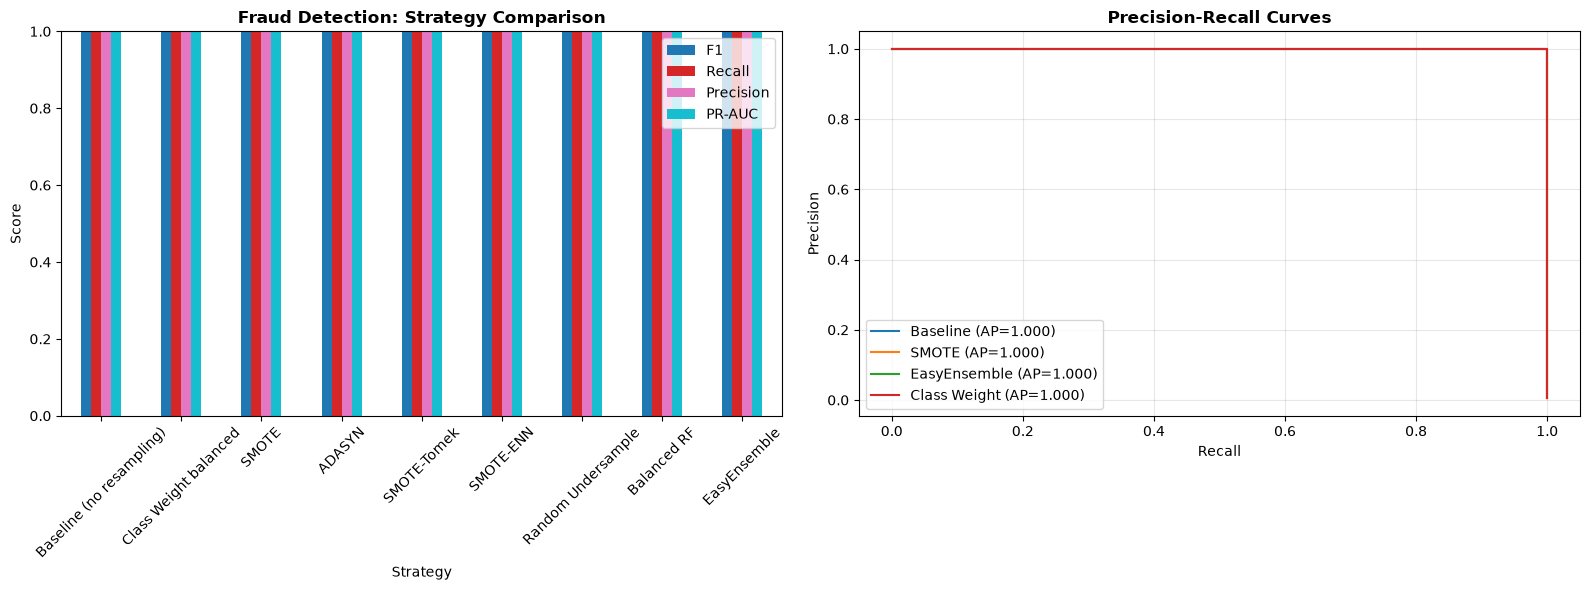


Full Results Table:
                           F1  Recall  Precision  ROC-AUC  PR-AUC
Strategy                                                         
Baseline (no resampling)  1.0     1.0        1.0      1.0     1.0
Class Weight balanced     1.0     1.0        1.0      1.0     1.0
SMOTE                     1.0     1.0        1.0      1.0     1.0
ADASYN                    1.0     1.0        1.0      1.0     1.0
SMOTE-Tomek               1.0     1.0        1.0      1.0     1.0
SMOTE-ENN                 1.0     1.0        1.0      1.0     1.0
Random Undersample        1.0     1.0        1.0      1.0     1.0
Balanced RF               1.0     1.0        1.0      1.0     1.0
EasyEnsemble              1.0     1.0        1.0      1.0     1.0


In [23]:
# Visualize fraud detection results
df_fraud_results = pd.DataFrame(fraud_results).set_index('Strategy')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
df_fraud_results[['F1', 'Recall', 'Precision', 'PR-AUC']].plot(
    kind='bar', ax=axes[0], rot=45, colormap='tab10'
)
axes[0].set_title('Fraud Detection: Strategy Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper right')

# Precision-Recall tradeoff (best model)
# Train best model for PR curve
best_idx = df_fraud_results['PR-AUC'].argmax()
best_name = df_fraud_results['PR-AUC'].idxmax()
print(f'Best strategy by PR-AUC: {best_name}')

# Train a few for PR curves
pr_models = [
    ('Baseline', RandomForestClassifier(n_estimators=100, random_state=42), None),
    ('SMOTE', RandomForestClassifier(n_estimators=100, random_state=42), SMOTE(random_state=42)),
    ('EasyEnsemble', EasyEnsembleClassifier(n_estimators=10, random_state=42), None),
    ('Class Weight', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), None),
]

for name, model, resampler in pr_models:
    try:
        if resampler:
            Xtr, ytr = resampler.fit_resample(X_f_train_sc, y_f_train)
        else:
            Xtr, ytr = X_f_train_sc, y_f_train
        model.fit(Xtr, ytr)
        y_prob = model.predict_proba(X_f_test_sc)[:, 1]
        prec, rec, _ = precision_recall_curve(y_f_test, y_prob)
        auc_val = average_precision_score(y_f_test, y_prob)
        axes[1].plot(rec, prec, label=f'{name} (AP={auc_val:.3f})')
    except Exception as e:
        print(f'PR curve {name}: {e}')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFull Results Table:')
print(df_fraud_results.round(4).to_string())


Final Fraud Detection Pipeline (SMOTE + Balanced RF)
  Cross-val F1:      1.0000 ± 0.0000
  Cross-val ROC-AUC: 1.0000 ± 0.0000



Test Set Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      2000
       Fraud       1.00      1.00      1.00        10

    accuracy                           1.00      2010
   macro avg       1.00      1.00      1.00      2010
weighted avg       1.00      1.00      1.00      2010



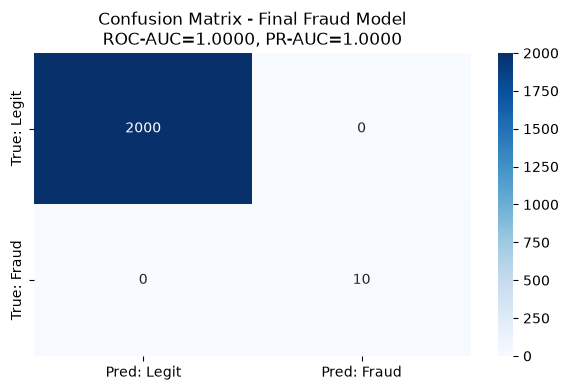


Business Impact:
  True Positives (fraud caught): 10
  False Negatives (fraud missed): 0
  False Positives (false alarms): 0
  Estimated fraud prevented: $8,000
  Cost of false alarms: $0
  Net benefit: $8,000


In [24]:
# Final best model: imblearn Pipeline with SMOTE + RandomForest
from imblearn.pipeline import Pipeline as ImbPipeline

fraud_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),  # don't fully balance use 0.3 ratio
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation with stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(fraud_pipeline, X_f_train, y_f_train, cv=skf, scoring='f1', n_jobs=-1)
cv_auc = cross_val_score(fraud_pipeline, X_f_train, y_f_train, cv=skf, scoring='roc_auc', n_jobs=-1)

print('Final Fraud Detection Pipeline (SMOTE + Balanced RF)')
print(f'  Cross-val F1:      {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  Cross-val ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

# Final test evaluation
fraud_pipeline.fit(X_f_train, y_f_train)
y_pred_final = fraud_pipeline.predict(X_f_test)
y_prob_final = fraud_pipeline.predict_proba(X_f_test)[:, 1]

print(f'\nTest Set Performance:')
print(classification_report(y_f_test, y_pred_final, target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_f_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['True: Legit', 'True: Fraud'])
ax.set_title(f'Confusion Matrix - Final Fraud Model\nROC-AUC={roc_auc_score(y_f_test, y_prob_final):.4f}, PR-AUC={average_precision_score(y_f_test, y_prob_final):.4f}')
plt.tight_layout()
plt.show()

# Business impact
tn, fp, fn, tp = cm.ravel()
print(f'\nBusiness Impact:')
print(f'  True Positives (fraud caught): {tp}')
print(f'  False Negatives (fraud missed): {fn}')
print(f'  False Positives (false alarms): {fp}')
avg_fraud_amount = 800
avg_fp_cost = 20
print(f'  Estimated fraud prevented: ${tp * avg_fraud_amount:,}')
print(f'  Cost of false alarms: ${fp * avg_fp_cost:,}')
print(f'  Net benefit: ${tp * avg_fraud_amount - fp * avg_fp_cost:,}')


## 9. Additional Learning Resources

### Foundational Papers

1. **SMOTE:** Chawla, N.V., Bowyer, K.W., Hall, L.O., & Kegelmeyer, W.P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research, 16, 321-357. [https://arxiv.org/abs/1106.1813](https://arxiv.org/abs/1106.1813)

2. **ADASYN:** He, H., Bai, Y., Garcia, E.A., & Li, S. (2008). *ADASYN: Adaptive Synthetic Sampling Approach for Imbalanced Learning*. IJCNN 2008. [https://ieeexplore.ieee.org/document/4633969](https://ieeexplore.ieee.org/document/4633969)

3. **Borderline-SMOTE:** Han, H., Wang, W.Y., & Mao, B.H. (2005). *Borderline-SMOTE: A New Over-Sampling Method in Imbalanced Data Sets Learning*. ICIC 2005. [https://link.springer.com/chapter/10.1007/11538059_91](https://link.springer.com/chapter/10.1007/11538059_91)

4. **EasyEnsemble & BalanceCascade:** Liu, X.Y., Wu, J., & Zhou, Z.H. (2009). *Exploratory Undersampling for Class-Imbalance Learning*. IEEE Transactions on Systems, Man, and Cybernetics, 39(2), 539-550. [https://ieeexplore.ieee.org/document/4717268](https://ieeexplore.ieee.org/document/4717268)

5. **RUSBoost:** Seiffert, C., Khoshgoftaar, T.M., Van Hulse, J., & Napolitano, A. (2010). *RUSBoost: A Hybrid Approach to Alleviating Class Imbalance*. IEEE Transactions on Systems, Man, and Cybernetics, 40(1), 185-197.

6. **Survey:** He, H., & Garcia, E.A. (2009). *Learning from Imbalanced Data*. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263-1284. [https://ieeexplore.ieee.org/document/5128907](https://ieeexplore.ieee.org/document/5128907)

### Libraries & Documentation

- **imbalanced-learn:** [https://imbalanced-learn.org/stable/](https://imbalanced-learn.org/stable/) Official docs with examples for every technique covered here
- **imbalanced-learn User Guide:** [https://imbalanced-learn.org/stable/user_guide.html](https://imbalanced-learn.org/stable/user_guide.html)
- **scikit-learn class_weight:** [https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html)

### Tutorials & Courses

- **Kaggle: Dealing with Imbalanced Data:** [https://www.kaggle.com/learn/](https://www.kaggle.com/learn/)
- **Kaggle Credit Card Fraud Dataset:** [https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) Real benchmark dataset with 0.17% fraud rate
- **Towards Data Science SMOTE Guide:** [https://towardsdatascience.com/smote-fdce2f605729](https://towardsdatascience.com/smote-fdce2f605729)
- **Elite Data Science Imbalanced Classes:** [https://elitedatascience.com/imbalanced-classes](https://elitedatascience.com/imbalanced-classes)

### Books

- **Learning from Imbalanced Datasets** by Alberto Fernández, Salvador García, Mikel Galar, et al. (2018, Springer) The most comprehensive textbook on this topic
- **Imbalanced Learning: Foundations, Algorithms, and Applications** edited by Haibo He & Yunqian Ma (2013, Wiley-IEEE)

### Key Takeaways

1. **Never use accuracy** as your primary metric for imbalanced data
2. **Start simple:** Try `class_weight='balanced'` first it's often surprisingly effective
3. **Ensemble methods** (BalancedRandomForest, EasyEnsemble) are usually the strongest performers
4. **SMOTE** is a good general-purpose oversampler; prefer **Borderline-SMOTE** for heavily overlapping classes
5. **Combined methods** (SMOTE-ENN) tend to outperform pure over/undersampling
6. **Always use stratified cross-validation** single train/test split can be misleading with rare classes
7. **Tune the decision threshold** 0.5 is rarely optimal for imbalanced problems
8. **Domain knowledge matters** understand the cost of false positives vs false negatives in your application
